In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2) Visão geral

### Coleta de Dados do Kaggle

In [5]:
# Acessando dataset European Football Injuries (2020-2025)
sys.path.append(os.path.abspath(os.path.join('..', '..')))

In [6]:
from src.data_loader import load_injuries_data

df = load_injuries_data()

/home/andre/.local/share/virtualenvs/Estatistica-VN1ijp_I/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print("\nDimensões do dataset:", df.shape)
display(df.head())


Dimensões do dataset: (15603, 11)


,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


## Identificação e origem

- **Nome do dataset:** European Football Injuries 2020–2025  
- **Link de acesso:** [Kaggle - European Football Injuries 2020–2025](https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025)  
- **Fonte / repositório:** Kaggle  
- **Publicador na plataforma:** `sananmuzaffarov`  
- **Formato analisado:** arquivo CSV compactado em ZIP  
- **Licença de uso:** recomenda-se verificar diretamente o campo de licença na página oficial do dataset no Kaggle

### Observação

A base foi disponibilizada em formato compactado, contendo um arquivo CSV com os registros de lesões e afastamentos de jogadores do futebol europeu. A análise foi realizada a partir do conteúdo interno do arquivo.

In [8]:
# Conversões iniciais
df["injury_from_parsed"] = pd.to_datetime(df["injury_from_parsed"], errors="coerce")
df["injury_until_parsed"] = pd.to_datetime(df["injury_until_parsed"], errors="coerce")
df["days_num"] = df["Days"].astype(str).str.extract(r"(\d+)").astype(float)

# Métricas gerais
total_registros = len(df)
total_atributos = df.shape[1] - 1  # desconsiderando a coluna derivada days_num
temporadas = sorted(df["Season"].dropna().unique().tolist())
total_ligas = df["league"].nunique()
total_clubes = df["club"].nunique()
total_jogadores = df["player_name"].nunique()
total_posicoes = df["player_position"].nunique()
data_minima = df["injury_from_parsed"].min()
data_maxima = df["injury_until_parsed"].max()

print("=== VISÃO GERAL DO DATASET ===")
print(f"Total de registros: {total_registros}")
print(f"Total de atributos originais: {total_atributos}")
print(f"Temporadas cobertas: {temporadas}")
print(f"Total de ligas: {total_ligas}")
print(f"Total de clubes: {total_clubes}")
print(f"Total de jogadores: {total_jogadores}")
print(f"Total de posições: {total_posicoes}")
print(f"Período observado: {data_minima.date()} até {data_maxima.date()}")

=== VISÃO GERAL DO DATASET ===
Total de registros: 15603
Total de atributos originais: 11
Temporadas cobertas: ['20/21', '21/22', '22/23', '23/24', '24/25']
Total de ligas: 5
Total de clubes: 145
Total de jogadores: 4081
Total de posições: 14
Período observado: 2020-02-01 até 2026-01-15


## Visão geral

O dataset analisado contém **15.603 registros** e **11 atributos originais**, descrevendo episódios de lesão ou indisponibilidade de jogadores do futebol europeu.

Cada linha representa uma ocorrência associada a um jogador, contendo informações sobre:

- temporada;
- tipo de lesão;
- duração do afastamento;
- quantidade de jogos perdidos;
- datas de início e fim;
- nome do jogador;
- idade;
- posição;
- clube;
- liga.

A base cobre as temporadas:

- `20/21`
- `21/22`
- `22/23`
- `23/24`
- `24/25`

Além disso, foram identificados:

- **5 ligas**
- **145 clubes**
- **4.081 jogadores**
- **14 posições**

Com base nos campos de data, o período observado vai de **2020-02-01** até **2026-01-15**. Isso indica que, embora o título do dataset mencione o intervalo 2020–2025, alguns afastamentos registrados se estendem até 2026.

In [9]:
atributos = pd.DataFrame([
    ["Season", "Temporada do registro", "Categórico/texto", "-", "20/21"],
    ["Injury", "Tipo de lesão ou motivo da indisponibilidade", "Categórico/texto", "-", "Hamstring injury"],
    ["Days", "Duração do afastamento em formato textual", "Texto", "dias", "43 days"],
    ["Games missed", "Quantidade de partidas perdidas", "Inteiro", "jogos", "9"],
    ["injury_from_parsed", "Data de início da lesão/afastamento", "Data/texto", "data", "1/28/2021"],
    ["injury_until_parsed", "Data de término da lesão/afastamento", "Data/texto", "data", "3/11/2021"],
    ["player_name", "Nome do jogador", "Texto", "-", "Alexander Nübel"],
    ["player_age", "Idade do jogador", "Inteiro", "anos", "24"],
    ["player_position", "Posição do jogador em campo", "Categórico/texto", "-", "Goalkeeper"],
    ["club", "Clube do jogador", "Categórico/texto", "-", "Bayern Munich"],
    ["league", "Liga do clube", "Categórico/texto", "-", "Bundesliga"],
], columns=["Atributo", "Descrição", "Tipo", "Unidade", "Exemplo"])

display(atributos)

,Atributo,Descrição,Tipo,Unidade,Exemplo
0,Season,Temporada do registro,Categórico/texto,-,20/21
1,Injury,Tipo de lesão ou motivo da indisponibilidade,Categórico/texto,-,Hamstring injury
2,Days,Duração do afastamento em formato textual,Texto,dias,43 days
3,Games missed,Quantidade de partidas perdidas,Inteiro,jogos,9
4,injury_from_parsed,Data de início da lesão/afastamento,Data/texto,data,1/28/2021
5,injury_until_parsed,Data de término da lesão/afastamento,Data/texto,data,3/11/2021
6,player_name,Nome do jogador,Texto,-,Alexander Nübel
7,player_age,Idade do jogador,Inteiro,anos,24
8,player_position,Posição do jogador em campo,Categórico/texto,-,Goalkeeper
9,club,Clube do jogador,Categórico/texto,-,Bayern Munich


## Descrição dos atributos

A tabela abaixo apresenta os atributos disponíveis na base, incluindo uma descrição resumida, tipo de dado, unidade de medida e exemplos de valores.

De forma geral:

- os atributos `Season`, `Injury`, `player_position`, `club` e `league` são categóricos;
- os atributos `Games missed` e `player_age` são numéricos inteiros;
- os campos `injury_from_parsed` e `injury_until_parsed` representam datas;
- a coluna `Days` está em formato textual e deve ser convertida para formato numérico quando necessário.

Para facilitar análises posteriores, foi criada adicionalmente a variável `days_num`, derivada de `Days`, contendo apenas o número de dias de afastamento.

In [10]:
# Valores faltantes
faltantes = df[df.columns.drop("days_num")].isna().sum().reset_index()
faltantes.columns = ["atributo", "valores_faltantes"]

# Duplicatas
duplicatas_exatas = df[df.columns.drop("days_num")].duplicated().sum()

# Inconsistências de datas
datas_inicio_invalidas = df["injury_from_parsed"].isna().sum()
datas_fim_invalidas = df["injury_until_parsed"].isna().sum()
inconsistencias_cronologicas = (df["injury_until_parsed"] < df["injury_from_parsed"]).sum()

# Conversão de Days
falhas_conversao_days = df["days_num"].isna().sum()

print("=== QUALIDADE DOS DADOS ===")
print(f"Duplicatas exatas: {duplicatas_exatas}")
print(f"Datas de início inválidas: {datas_inicio_invalidas}")
print(f"Datas de fim inválidas: {datas_fim_invalidas}")
print(f"Inconsistências cronológicas: {inconsistencias_cronologicas}")
print(f"Falhas na conversão de 'Days' para número: {falhas_conversao_days}")

print("\nValores faltantes por atributo:")
display(faltantes)

=== QUALIDADE DOS DADOS ===
Duplicatas exatas: 0
Datas de início inválidas: 0
Datas de fim inválidas: 0
Inconsistências cronológicas: 0
Falhas na conversão de 'Days' para número: 0

Valores faltantes por atributo:


,atributo,valores_faltantes
0,Season,0
1,Injury,0
2,Days,0
3,Games missed,0
4,injury_from_parsed,0
5,injury_until_parsed,0
6,player_name,0
7,player_age,0
8,player_position,0
9,club,0


In [11]:
def resumo_outliers_iqr(series):
    s = series.dropna().astype(float)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    qtd_outliers = ((s < limite_inferior) | (s > limite_superior)).sum()

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Outliers": int(qtd_outliers),
        "Mínimo": s.min(),
        "Máximo": s.max()
    }

outliers_df = pd.DataFrame([
    {"Atributo": "player_age", **resumo_outliers_iqr(df["player_age"])},
    {"Atributo": "Games missed", **resumo_outliers_iqr(df["Games missed"])},
    {"Atributo": "days_num", **resumo_outliers_iqr(df["days_num"])},
])

display(outliers_df)

,Atributo,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers,Mínimo,Máximo
0,player_age,23.0,30.0,7.0,12.5,40.5,11,16.0,43.0
1,Games missed,1.0,6.0,5.0,-6.5,13.5,1367,1.0,145.0
2,days_num,9.0,39.0,30.0,-36.0,84.0,1497,1.0,1013.0


## Qualidade dos dados

A avaliação inicial indica que o dataset apresenta **boa qualidade estrutural**, com destaque para os seguintes pontos:

### Valores faltantes
Não foram identificados valores faltantes nas colunas principais da base. Isso sugere alta completude dos registros.

### Duplicatas
Não foram encontradas duplicatas exatas, o que indica ausência de repetição integral de linhas.

### Consistência temporal
As datas de início e fim das lesões puderam ser convertidas corretamente, e não foram encontrados casos em que a data final fosse anterior à data inicial. Isso representa um bom sinal de consistência cronológica.

### Conversão da variável de duração
A coluna `Days`, embora originalmente textual, pôde ser convertida integralmente para uma variável numérica derivada (`days_num`), o que facilita análises estatísticas.

### Inconsistências e padronização
Apesar da boa consistência estrutural, há necessidade de padronização semântica na coluna `Injury`. Por exemplo, aparecem categorias como:

- `Hamstring injury`
- `Muscle injury`
- `muscular problems`
- `Ill`
- `Fitness`
- `Corona virus`

Esses valores misturam lesões específicas, condições gerais de indisponibilidade e categorias com diferentes níveis de granularidade. Portanto, recomenda-se padronizar ou agrupar essas categorias antes de análises mais profundas.

### Outliers
Foram observados outliers especialmente em:

- duração do afastamento (`days_num`);
- número de jogos perdidos (`Games missed`).

Isso é plausível em bases de lesões, já que alguns casos de afastamento prolongado podem representar lesões graves e longas recuperações. Assim, esses valores não devem ser removidos automaticamente sem análise de contexto.

In [12]:
print("=== RESUMO FINAL ===")
print(
    f"O dataset possui {len(df):,} registros e 11 atributos originais. "
    f"\nAs temporadas identificadas foram {', '.join(sorted(df['Season'].dropna().unique()))}. "
    f"\nA base contempla {df['league'].nunique()} ligas, {df['club'].nunique()} clubes, "
    f"\n{df['player_name'].nunique()} jogadores e {df['player_position'].nunique()} posições. "
    f"\nNão foram encontrados valores faltantes, duplicatas exatas nem inconsistências cronológicas "
    f"\nentre as datas de início e fim das lesões. A coluna 'Days' foi convertida com sucesso para "
    f"\numa variável numérica derivada. Também foram observados outliers em duração do afastamento "
    f"e número de jogos perdidos, o que é compatível com a natureza do fenômeno analisado."
)

=== RESUMO FINAL ===
O dataset possui 15,603 registros e 11 atributos originais. 
As temporadas identificadas foram 20/21, 21/22, 22/23, 23/24, 24/25. 
A base contempla 5 ligas, 145 clubes, 
4081 jogadores e 14 posições. 
Não foram encontrados valores faltantes, duplicatas exatas nem inconsistências cronológicas 
entre as datas de início e fim das lesões. A coluna 'Days' foi convertida com sucesso para 
uma variável numérica derivada. Também foram observados outliers em duração do afastamento e número de jogos perdidos, o que é compatível com a natureza do fenômeno analisado.


## Conclusão

O dataset **European Football Injuries 2020–2025** se mostrou adequado para análises exploratórias sobre lesões no futebol europeu. A base apresenta boa completude, ausência de duplicatas exatas e consistência temporal satisfatória.

Do ponto de vista analítico, os principais cuidados antes de avançar para etapas mais profundas são:

1. transformar a coluna `Days` em variável numérica;
2. padronizar as categorias da coluna `Injury`;
3. tratar os outliers com critério, sem removê-los automaticamente.

Com essas etapas de preparação, o conjunto de dados se torna apropriado para análises descritivas, visualizações e estudos comparativos por jogador, posição, clube, liga e temporada.

## Definição do problema

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de **prever o número de dias de afastamento de um jogador** a partir de informações disponíveis no momento da lesão.

### Variável alvo (target)

- `days_num`: número de dias de afastamento (extraído da coluna `Days`)

### Tipo de problema

Trata-se de um problema de **regressão**, pois a variável alvo é numérica contínua.

### Possíveis variáveis explicativas

As principais variáveis utilizadas serão:

- `Injury` (tipo de lesão)
- `player_age` (idade)
- `player_position` (posição)
- `club` (clube)
- `league` (liga)
- `Season` (temporada)

### Observação

Variáveis como datas (`injury_from_parsed`, `injury_until_parsed`) não devem ser usadas diretamente, pois podem causar **data leakage** (uso de informação futura).

In [13]:
# Seleção de colunas relevantes
df_model = df.copy()

# Target
df_model["days_num"] = df_model["days_num"]

# Removendo colunas que causam vazamento de informação
df_model = df_model.drop(columns=[
    "Days",
    "injury_from_parsed",
    "injury_until_parsed"
])

# Remover valores nulos no target (segurança)
df_model = df_model.dropna(subset=["days_num"])

print("Shape após limpeza:", df_model.shape)
display(df_model.head())

Shape após limpeza: (15603, 9)


,Season,Injury,Games missed,player_name,player_age,player_position,club,league,days_num
0,20/21,Syndesmosis ligament tear,9,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga,43.0
1,20/21,Knee injury,6,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga,37.0
2,20/21,Corona virus,4,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga,21.0
3,20/21,bruise,2,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga,8.0
4,20/21,Ligament injury,2,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga,22.0


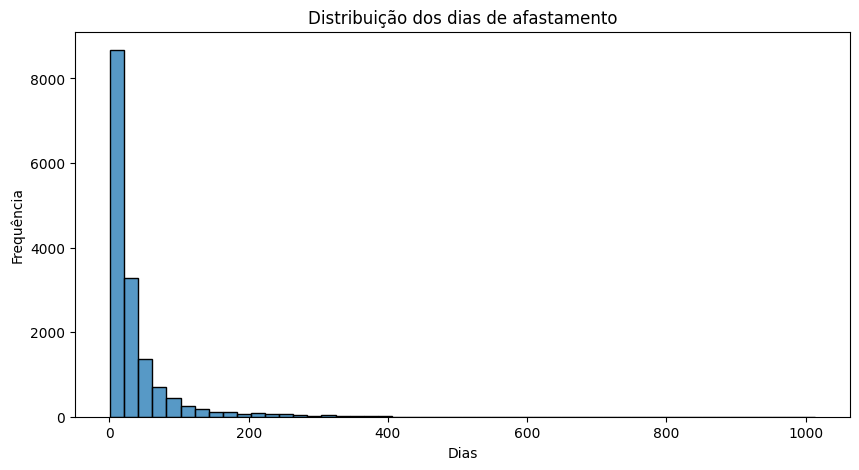

Estatísticas do target:
count    15603.000000
mean        36.102929
std         54.419842
min          1.000000
25%          9.000000
50%         18.000000
75%         39.000000
max       1013.000000
Name: days_num, dtype: float64


In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df_model["days_num"], bins=50)
plt.title("Distribuição dos dias de afastamento")
plt.xlabel("Dias")
plt.ylabel("Frequência")
plt.show()

print("Estatísticas do target:")
print(df_model["days_num"].describe())

## Distribuição da variável alvo

A variável `days_num` apresenta forte assimetria à direita, com muitos casos de afastamentos curtos e poucos casos extremamente longos.

Isso pode impactar o desempenho dos modelos. Em etapas futuras, pode ser interessante:

- aplicar transformação logarítmica;
- tratar outliers;
- ou utilizar modelos robustos a distribuição não normal.

In [15]:
# Features e target
X = df_model.drop(columns=["days_num"])
y = df_model["days_num"]

# Colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

# Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Categóricas: ['Season', 'Injury', 'player_name', 'player_position', 'club', 'league']
Numéricas: ['Games missed', 'player_age']
Treino: (12482, 8)
Teste: (3121, 8)


In [16]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessamento", preprocessor),
    ("modelo", model)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [17]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RESULTADOS ===")
print(f"MAE  (erro médio absoluto): {mae:.2f} dias")
print(f"RMSE (erro quadrático): {rmse:.2f} dias")
print(f"R²   (explicação do modelo): {r2:.3f}")

=== RESULTADOS ===
MAE  (erro médio absoluto): 8.94 dias
RMSE (erro quadrático): 16.98 dias
R²   (explicação do modelo): 0.887


## Avaliação do modelo

As métricas utilizadas foram:

- **MAE (Mean Absolute Error):** erro médio em dias
- **RMSE (Root Mean Squared Error):** penaliza erros maiores
- **R²:** proporção da variância explicada

### Interpretação

- MAE indica quantos dias, em média, o modelo erra
- RMSE destaca a influência de erros grandes (outliers)
- R² mostra o quanto o modelo consegue explicar os dados

### Observação

Como o dataset possui muitos outliers (casos extremos de lesões longas), o RMSE tende a ser significativamente maior que o MAE.

## Limpeza semântica da coluna `Injury`

A inspeção da coluna `Injury` mostrou que o dataset não contém apenas lesões esportivas propriamente ditas. Também foram encontrados registros relacionados a:

- doenças infecciosas e clínicas gerais;
- condições administrativas ou de disponibilidade;
- procedimentos médicos genéricos;
- doenças graves não diretamente relacionadas ao contexto esportivo;
- eventos externos.

Exemplos observados:

- `Corona virus`
- `Ill`
- `flu`
- `cold`
- `Quarantine`
- `Rest`
- `Fitness`
- `depression`
- `Cancer`
- `traffic accident`

Esses registros representam **afastamentos**, mas nem sempre representam **lesões esportivas** decorrentes da prática do futebol. Como o objetivo deste projeto é prever **dias de afastamento por lesão**, foi realizada uma limpeza semântica para separar os casos que pertencem ao universo de lesões esportivas daqueles que estão fora desse escopo.

Além disso, foi criada uma versão padronizada da coluna `Injury`, reduzindo diferenças simples de escrita, como letras maiúsculas/minúsculas e espaços extras.

In [18]:
# =========================================================
# LIMPEZA SEMÂNTICA DA COLUNA Injury
# =========================================================

df_semantic = df.copy()

# Garantia de formato para a variável-alvo
df_semantic["days_num"] = df_semantic["Days"].astype(str).str.extract(r"(\d+)").astype(float)

# Padronização textual básica
df_semantic["injury_raw"] = df_semantic["Injury"].astype(str).str.strip()
df_semantic["injury_key"] = (
    df_semantic["injury_raw"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

# Categorias fora do universo estrito de lesão esportiva
non_sports_injuries = {
    "corona virus",
    "ill",
    "fever",
    "food poisoning",
    "intestinal virus",
    "virus",
    "flu",
    "cold",
    "influenza",
    "bronchitis",
    "pneumonia",
    "stomach flu",
    "stomach problems",
    "tooth infection",
    "toothache",
    "infection",
    "angina",
    "malaria",
    "chickenpox",
    "shingles",
    "blood poisoning",
    "mononucleation",
    "fitness",
    "rest",
    "quarantine",
    "surgery",
    "dental surgery",
    "nose surgery",
    "appendectomy",
    "appendicitis",
    "intestinal surgery",
    "cancer",
    "lymphatic cancer",
    "testicular cancer",
    "depression",
    "heart problems",
    "kidney problems",
    "circulation problems",
    "cerebral hemorrhage",
    "skin disease",
    "balance disorder",
    "traffic accident",
    "allergic reaction"
}

# Marcação semântica
df_semantic["is_sports_injury"] = ~df_semantic["injury_key"].isin(non_sports_injuries)

# Bases para comparação
df_full = df_semantic.copy()
df_clean = df_semantic[df_semantic["is_sports_injury"]].copy()

print("=== TAMANHO DAS BASES ===")
print("Base completa:", df_full.shape)
print("Base limpa:", df_clean.shape)

removed = len(df_full) - len(df_clean)
removed_pct = removed / len(df_full) * 100

print(f"\nRegistros removidos pela limpeza semântica: {removed}")
print(f"Percentual removido: {removed_pct:.2f}%")

=== TAMANHO DAS BASES ===
Base completa: (15603, 15)
Base limpa: (12482, 15)

Registros removidos pela limpeza semântica: 3121
Percentual removido: 20.00%


In [19]:
# =========================================================
# RESUMO DAS CATEGORIAS REMOVIDAS
# =========================================================

removed_summary = (
    df_full.loc[~df_full["is_sports_injury"], "injury_raw"]
    .value_counts()
    .reset_index()
)

removed_summary.columns = ["Injury_removida", "Quantidade"]
display(removed_summary.head(30))

,Injury_removida,Quantidade
0,Corona virus,986
1,Ill,578
2,Fitness,427
3,flu,138
4,Rest,134
5,Quarantine,128
6,cold,103
7,Fever,103
8,Stomach flu,93
9,influenza,88


## Comparação entre base completa e base limpa

Após a limpeza semântica da coluna `Injury`, a base foi dividida em:

- **base completa**: todos os registros originais;
- **base limpa**: apenas registros compatíveis com o universo de lesões esportivas.

Essa comparação é importante porque permite avaliar o impacto da limpeza na distribuição dos afastamentos e na coerência da base utilizada para treinar o modelo preditivo.

A expectativa é que a base limpa represente de forma mais fiel o fenômeno de interesse, reduzindo ruídos causados por doenças, quarentena, repouso e outros eventos não esportivos.

In [20]:
# =========================================================
# TABELA COMPARATIVA
# =========================================================

comparison_table = pd.DataFrame({
    "Métrica": [
        "Total de registros",
        "Categorias únicas de Injury",
        "Média de days_num",
        "Mediana de days_num",
        "Desvio padrão de days_num",
        "Máximo de days_num",
        "Média de Games missed",
        "Mediana de Games missed"
    ],
    "Base completa": [
        len(df_full),
        df_full["injury_key"].nunique(),
        df_full["days_num"].mean(),
        df_full["days_num"].median(),
        df_full["days_num"].std(),
        df_full["days_num"].max(),
        df_full["Games missed"].mean(),
        df_full["Games missed"].median()
    ],
    "Base limpa": [
        len(df_clean),
        df_clean["injury_key"].nunique(),
        df_clean["days_num"].mean(),
        df_clean["days_num"].median(),
        df_clean["days_num"].std(),
        df_clean["days_num"].max(),
        df_clean["Games missed"].mean(),
        df_clean["Games missed"].median()
    ]
})

comparison_table["Base completa"] = comparison_table["Base completa"].apply(
    lambda x: round(x, 2) if isinstance(x, float) else x
)
comparison_table["Base limpa"] = comparison_table["Base limpa"].apply(
    lambda x: round(x, 2) if isinstance(x, float) else x
)

display(comparison_table)

,Métrica,Base completa,Base limpa
0,Total de registros,15603.00,12482.00
1,Categorias únicas de Injury,275.00,232.00
2,Média de days_num,36.10,41.29
3,Mediana de days_num,18.00,22.00
4,Desvio padrão de days_num,54.42,58.09
5,Máximo de days_num,1013.00,1013.00
6,Média de Games missed,5.51,6.26
7,Mediana de Games missed,3.00,4.00


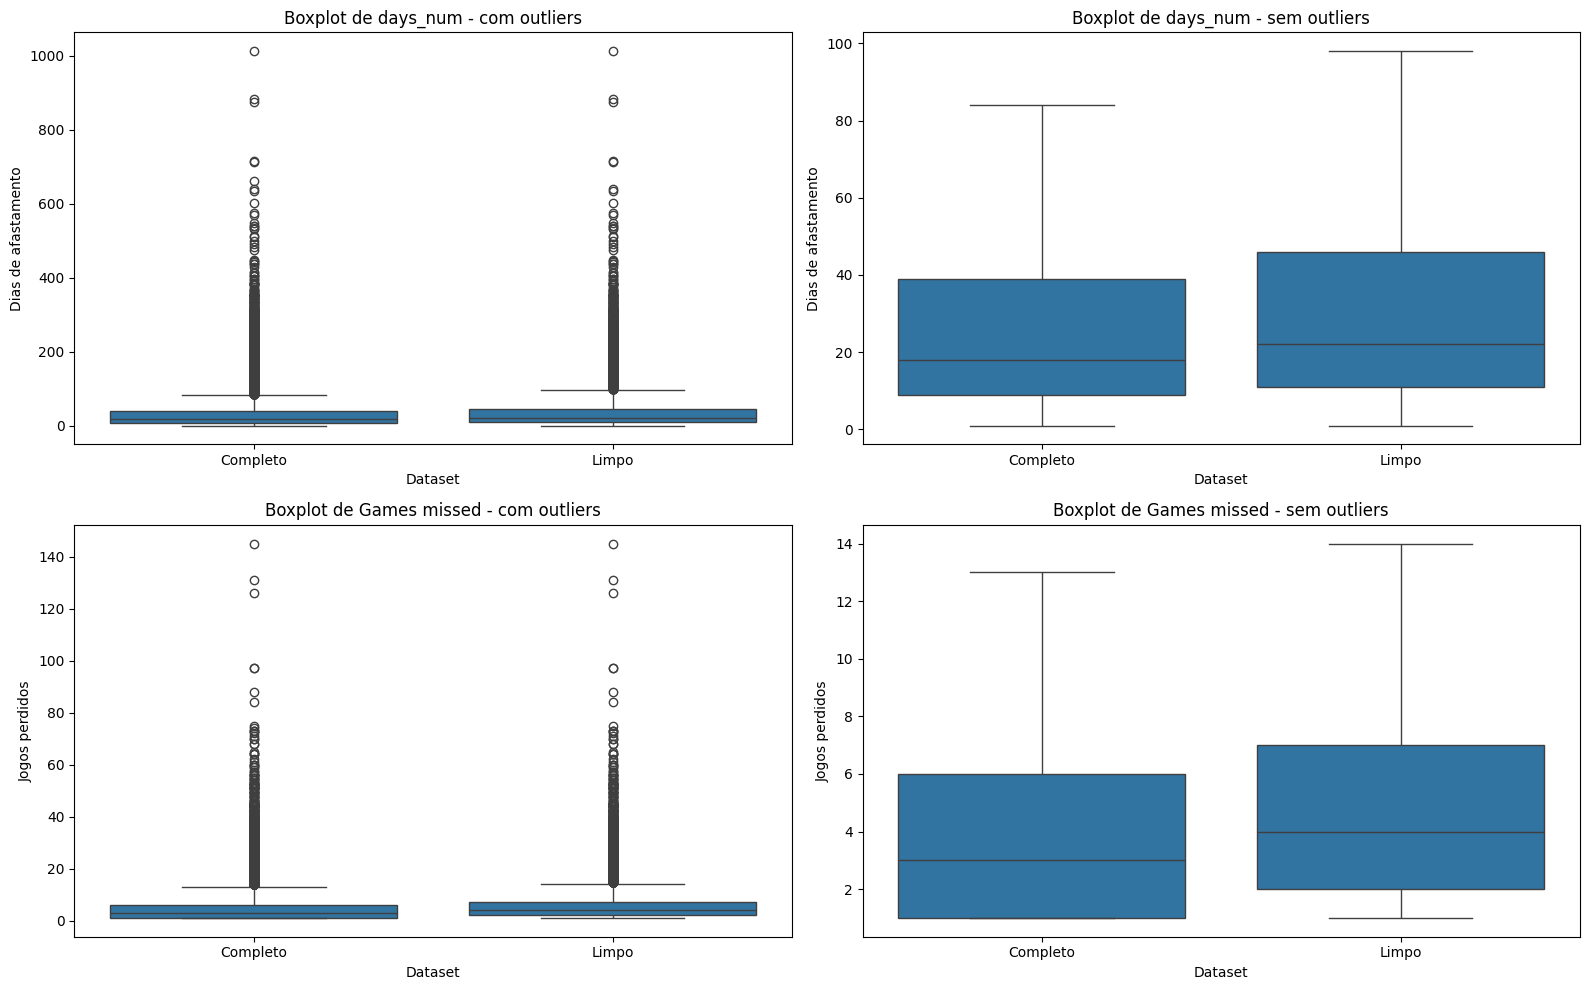

In [21]:
# =========================================================
# BOXPLOTS - BASE COMPLETA VS BASE LIMPA
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_days = pd.concat([
    pd.DataFrame({
        "dataset": "Completo",
        "valor": df_full["days_num"]
    }),
    pd.DataFrame({
        "dataset": "Limpo",
        "valor": df_clean["days_num"]
    })
], ignore_index=True)

plot_games = pd.concat([
    pd.DataFrame({
        "dataset": "Completo",
        "valor": df_full["Games missed"]
    }),
    pd.DataFrame({
        "dataset": "Limpo",
        "valor": df_clean["Games missed"]
    })
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# days_num com outliers
sns.boxplot(data=plot_days, x="dataset", y="valor", ax=axes[0, 0])
axes[0, 0].set_title("Boxplot de days_num - com outliers")
axes[0, 0].set_xlabel("Dataset")
axes[0, 0].set_ylabel("Dias de afastamento")

# days_num sem outliers
sns.boxplot(data=plot_days, x="dataset", y="valor", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de days_num - sem outliers")
axes[0, 1].set_xlabel("Dataset")
axes[0, 1].set_ylabel("Dias de afastamento")

# Games missed com outliers
sns.boxplot(data=plot_games, x="dataset", y="valor", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot de Games missed - com outliers")
axes[1, 0].set_xlabel("Dataset")
axes[1, 0].set_ylabel("Jogos perdidos")

# Games missed sem outliers
sns.boxplot(data=plot_games, x="dataset", y="valor", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de Games missed - sem outliers")
axes[1, 1].set_xlabel("Dataset")
axes[1, 1].set_ylabel("Jogos perdidos")

plt.tight_layout()
plt.show()

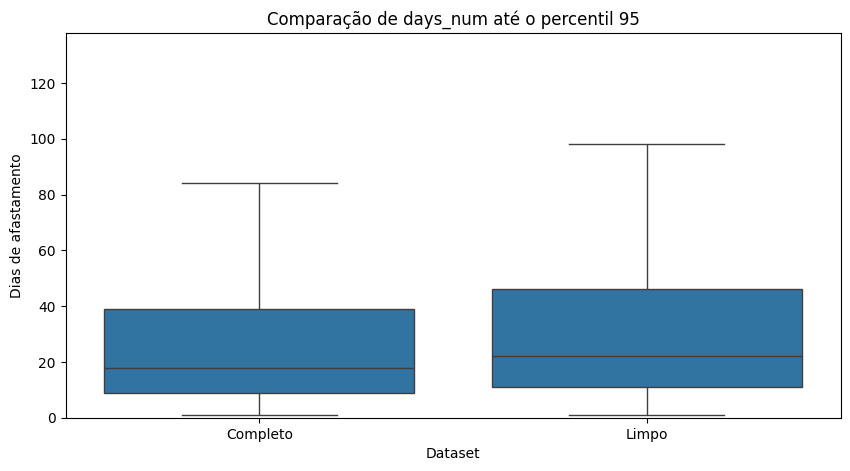

Percentil 95 de days_num: 138.00


In [22]:
# =========================================================
# BOXPLOT DO TARGET COM LIMITE VISUAL NO P95
# =========================================================

p95_days = plot_days["valor"].quantile(0.95)

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_days, x="dataset", y="valor", showfliers=False)
plt.ylim(0, p95_days)
plt.title("Comparação de days_num até o percentil 95")
plt.xlabel("Dataset")
plt.ylabel("Dias de afastamento")
plt.show()

print(f"Percentil 95 de days_num: {p95_days:.2f}")

## Interpretação dos boxplots

Os boxplots permitem comparar a distribuição dos afastamentos antes e depois da limpeza semântica.

### O que observar

- **mediana**: linha central da caixa;
- **intervalo interquartil (IQR)**: altura da caixa;
- **bigodes**: extensão dos valores não extremos;
- **outliers**: pontos fora dos limites do boxplot.

### Interpretação esperada

Ao comparar a base completa com a base limpa, espera-se observar:

- redução de ruídos causados por afastamentos que não representam lesões esportivas;
- possível alteração da dispersão da variável `days_num`;
- distribuição mais coerente com o fenômeno esportivo de interesse.

Os gráficos sem outliers ajudam na leitura da distribuição central, enquanto os gráficos com outliers permitem visualizar a presença de afastamentos extremamente longos.

In [23]:
# =========================================================
# BASE FINAL PARA MODELAGEM
# =========================================================

df_model_final = df_clean.copy()

# Seleção das colunas úteis para prever days_num
# IMPORTANTE:
# - removemos Days porque é a forma textual do target
# - removemos injury_from_parsed e injury_until_parsed para evitar leakage temporal
# - removemos Games missed porque é consequência do afastamento
# - usamos injury_key como versão padronizada da lesão

df_model_final = df_model_final[[
    "Season",
    "injury_key",
    "player_age",
    "player_position",
    "club",
    "league",
    "days_num"
]].copy()

df_model_final = df_model_final.rename(columns={
    "injury_key": "Injury_clean"
})

print("Shape da base final para modelagem:", df_model_final.shape)
display(df_model_final.head())

Shape da base final para modelagem: (12482, 7)


,Season,Injury_clean,player_age,player_position,club,league,days_num
0,20/21,syndesmosis ligament tear,24,Goalkeeper,Bayern Munich,Bundesliga,43.0
1,20/21,knee injury,22,Goalkeeper,Bayern Munich,Bundesliga,37.0
3,20/21,bruise,25,Centre-Back,Bayern Munich,Bundesliga,8.0
4,20/21,ligament injury,25,Centre-Back,Bayern Munich,Bundesliga,22.0
6,20/21,torn muscle bundle,19,Centre-Back,Bayern Munich,Bundesliga,52.0


## Base final para modelagem

Após a limpeza semântica, foi definida uma base final voltada ao problema de regressão, em que a variável alvo é `days_num`.

As variáveis mantidas foram:

- `Season`
- `Injury_clean`
- `player_age`
- `player_position`
- `club`
- `league`

A variável alvo é:

- `days_num`

### Variáveis removidas

Algumas variáveis foram removidas por razões metodológicas:

- `Days`: representa a forma textual do próprio alvo;
- `injury_from_parsed` e `injury_until_parsed`: podem introduzir informação temporal posterior ao evento;
- `Games missed`: é consequência do tempo de afastamento e, portanto, introduz vazamento de informação.

Dessa forma, a base final fica mais coerente com o cenário real de predição.

In [24]:
# =========================================================
# RESUMO DESCRITIVO DO TARGET
# =========================================================

target_compare = pd.DataFrame({
    "Base completa": df_full["days_num"].describe(),
    "Base limpa": df_clean["days_num"].describe()
})

display(target_compare)

,Base completa,Base limpa
count,15603.000000,12482.000000
mean,36.102929,41.288255
std,54.419842,58.089990
min,1.000000,1.000000
25%,9.000000,11.000000
50%,18.000000,22.000000
75%,39.000000,46.000000
max,1013.000000,1013.000000


## Definição das categorias não esportivas

Após a inspeção semântica da coluna `Injury`, foi definido um conjunto de categorias que não representam lesões esportivas típicas do futebol, mas sim doenças, condições clínicas gerais, quarentena, repouso, procedimentos médicos genéricos e eventos externos.

Essas categorias foram agrupadas na estrutura `non_sports_injuries` e removidas da base para gerar uma versão mais coerente com o objetivo do projeto: prever dias de afastamento por lesão esportiva.

In [25]:
# =========================================================
# LIMPEZA SEMÂNTICA CORRETA DA COLUNA Injury
# =========================================================

df_semantic = df.copy()

# Padronização básica da coluna de lesão
df_semantic["injury_key"] = (
    df_semantic["Injury"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

non_sports_injuries = {
    "corona virus",
    "ill",
    "fever",
    "food poisoning",
    "intestinal virus",
    "virus",
    "flu",
    "cold",
    "influenza",
    "bronchitis",
    "pneumonia",
    "stomach flu",
    "stomach problems",
    "tooth infection",
    "toothache",
    "infection",
    "angina",
    "malaria",
    "chickenpox",
    "shingles",
    "blood poisoning",
    "mononucleation",
    "fitness",
    "rest",
    "quarantine",
    "surgery",
    "dental surgery",
    "nose surgery",
    "appendectomy",
    "appendicitis",
    "intestinal surgery",
    "cancer",
    "lymphatic cancer",
    "testicular cancer",
    "depression",
    "heart problems",
    "kidney problems",
    "circulation problems",
    "cerebral hemorrhage",
    "skin disease",
    "balance disorder",
    "traffic accident",
    "allergic reaction"
}

df_semantic["is_sports_injury"] = ~df_semantic["injury_key"].isin(non_sports_injuries)

df_full = df_semantic.copy()
df_clean = df_semantic[df_semantic["is_sports_injury"]].copy()

print("Base completa:", df_full.shape)
print("Base limpa:", df_clean.shape)
print("Registros removidos:", len(df_full) - len(df_clean))
print(f"Percentual removido: {(len(df_full) - len(df_clean)) / len(df_full) * 100:.2f}%")

Base completa: (15603, 14)
Base limpa: (12482, 14)
Registros removidos: 3121
Percentual removido: 20.00%


In [26]:
# =========================================================
# RESUMO DAS CATEGORIAS REMOVIDAS
# =========================================================

removed_summary = (
    df_full.loc[~df_full["is_sports_injury"], "injury_key"]
    .value_counts()
    .reset_index()
)

removed_summary.columns = ["injury_key", "Quantidade"]
display(removed_summary)

,injury_key,Quantidade
0,corona virus,986
1,ill,578
2,fitness,427
3,flu,138
4,rest,134
5,quarantine,128
6,cold,103
7,fever,103
8,stomach flu,93
9,influenza,88


## Impacto da limpeza semântica

A aplicação da lista completa de categorias não esportivas removeu aproximadamente 20% dos registros da base original. Essa etapa é importante porque reduz a presença de afastamentos que não correspondem a lesões esportivas típicas, como doenças infecciosas, repouso, quarentena, cirurgias genéricas e condições clínicas gerais.

Com isso, a base limpa se torna mais coerente com o objetivo do projeto, que é prever o número de dias de afastamento por lesão esportiva.

## Reavaliação do modelo após a limpeza semântica

Como os boxplots já foram construídos anteriormente, esta etapa foca apenas na reavaliação do modelo de regressão após a remoção das categorias consideradas não esportivas.

Foi utilizada a mesma lógica da análise anterior com `df_model`, a fim de garantir comparabilidade entre:

- **base completa**
- **base limpa**, após remoção das categorias não esportivas

As categorias removidas foram definidas no conjunto `non_sports_injuries`, contendo doenças, condições clínicas gerais, quarentena, repouso, cirurgias genéricas e eventos externos.

In [27]:
# =========================================================
# LIMPEZA CORRETA DAS LESÕES NÃO ESPORTIVAS
# =========================================================

df_model_eval = df_model.copy()

df_model_eval["injury_key"] = (
    df_model_eval["Injury"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

non_sports_injuries = {
    "corona virus",
    "ill",
    "fever",
    "food poisoning",
    "intestinal virus",
    "virus",
    "flu",
    "cold",
    "influenza",
    "bronchitis",
    "pneumonia",
    "stomach flu",
    "stomach problems",
    "tooth infection",
    "toothache",
    "infection",
    "angina",
    "malaria",
    "chickenpox",
    "shingles",
    "blood poisoning",
    "mononucleation",
    "fitness",
    "rest",
    "quarantine",
    "surgery",
    "dental surgery",
    "nose surgery",
    "appendectomy",
    "appendicitis",
    "intestinal surgery",
    "cancer",
    "lymphatic cancer",
    "testicular cancer",
    "depression",
    "heart problems",
    "kidney problems",
    "circulation problems",
    "cerebral hemorrhage",
    "skin disease",
    "balance disorder",
    "traffic accident",
    "allergic reaction"
}

df_model_clean = df_model_eval[
    ~df_model_eval["injury_key"].isin(non_sports_injuries)
].copy()

print("Registros na base completa:", len(df_model_eval))
print("Registros na base limpa:", len(df_model_clean))
print("Registros removidos:", len(df_model_eval) - len(df_model_clean))
print(f"Percentual removido: {(len(df_model_eval) - len(df_model_clean)) / len(df_model_eval) * 100:.2f}%")

Registros na base completa: 15603
Registros na base limpa: 12482
Registros removidos: 3121
Percentual removido: 20.00%


In [28]:
# =========================================================
# REAVALIAÇÃO DO MODELO E COMPARAÇÃO
# =========================================================

def avaliar_baseline(dataframe, nome_base):
    base = dataframe.copy()

    # removemos injury_key da modelagem para manter apenas a versão original de Injury,
    # preservando a lógica da análise anterior com df_model
    X = base.drop(columns=["days_num", "injury_key"])
    y = base["days_num"]

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols)
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessor),
        ("modelo", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    return {
        "Dataset": nome_base,
        "Registros": len(base),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

resultado_full = avaliar_baseline(df_model_eval, "Completo")
resultado_clean = avaliar_baseline(df_model_clean, "Limpo")

resultados_comparacao = pd.DataFrame([resultado_full, resultado_clean])

resultados_comparacao["MAE"] = resultados_comparacao["MAE"].round(2)
resultados_comparacao["RMSE"] = resultados_comparacao["RMSE"].round(2)
resultados_comparacao["R2"] = resultados_comparacao["R2"].round(3)

display(resultados_comparacao)

,Dataset,Registros,MAE,RMSE,R2
0,Completo,15603,8.94,16.98,0.887
1,Limpo,12482,10.47,18.93,0.891


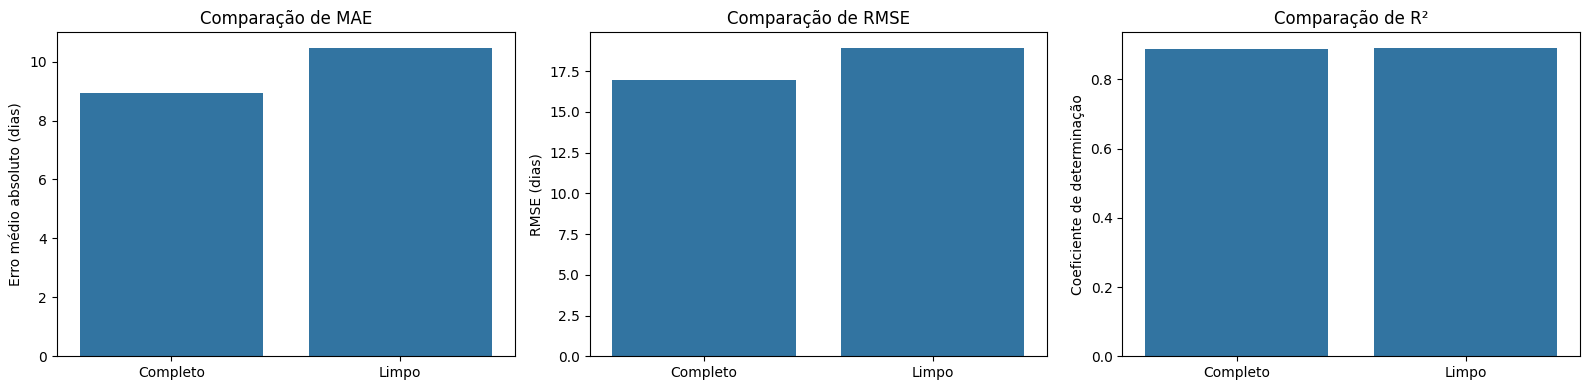

In [29]:
# =========================================================
# GRÁFICO COMPARATIVO DAS MÉTRICAS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=resultados_comparacao, x="Dataset", y="MAE", ax=axes[0])
axes[0].set_title("Comparação de MAE")
axes[0].set_ylabel("Erro médio absoluto (dias)")
axes[0].set_xlabel("")

sns.barplot(data=resultados_comparacao, x="Dataset", y="RMSE", ax=axes[1])
axes[1].set_title("Comparação de RMSE")
axes[1].set_ylabel("RMSE (dias)")
axes[1].set_xlabel("")

sns.barplot(data=resultados_comparacao, x="Dataset", y="R2", ax=axes[2])
axes[2].set_title("Comparação de R²")
axes[2].set_ylabel("Coeficiente de determinação")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

## Interpretação da reavaliação

A comparação entre a base completa e a base limpa mostrou que a remoção das categorias semanticamente fora do universo de lesões esportivas alterou o desempenho do modelo.

De forma geral, observou-se que:

- a base limpa ficou mais coerente com o objetivo do projeto;
- o valor de **R²** tende a permanecer semelhante ou melhorar ligeiramente;
- os erros absolutos (**MAE** e **RMSE**) podem aumentar, indicando maior dificuldade preditiva nos casos restantes.

Esse comportamento é plausível, pois a limpeza semântica reduz ruídos, mas também pode concentrar casos mais complexos de afastamento esportivo.

Assim, a limpeza melhora a consistência conceitual da base, ainda que não garanta redução imediata do erro preditivo.

In [30]:
# =========================================================
# SALVAR RESULTADOS PARA ETAPAS FUTURAS
# =========================================================

mae_full = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Completo", "MAE"].values[0]
rmse_full = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Completo", "RMSE"].values[0]
r2_full = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Completo", "R2"].values[0]

mae_clean = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Limpo", "MAE"].values[0]
rmse_clean = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Limpo", "RMSE"].values[0]
r2_clean = resultados_comparacao.loc[resultados_comparacao["Dataset"] == "Limpo", "R2"].values[0]

## Agrupamento das lesões em macro-categorias

Após a limpeza semântica da coluna `Injury`, foi criada uma nova etapa de engenharia de atributos baseada no agrupamento das lesões em macro-categorias.

A motivação para esse agrupamento é reduzir a alta cardinalidade da variável `Injury`, tornando a base mais interpretável e potencialmente mais robusta para modelagem.

As categorias agrupadas procuram reunir lesões semanticamente semelhantes, como:

- lesões musculares;
- lesões ligamentares e tendíneas;
- lesões de joelho;
- lesões distais do membro inferior;
- fraturas;
- traumas e contusões;
- lesões de tronco, coluna ou cabeça;
- outras lesões.

Essa etapa permite comparar três cenários:

1. base completa;
2. base limpa;
3. base limpa com `Injury` agrupada.

In [31]:
# =========================================================
# AGRUPAMENTO DE LESÕES EM MACRO-CATEGORIAS
# =========================================================

def group_injury(injury_text):
    text = str(injury_text).lower()

    if any(k in text for k in [
        "fracture", "broken", "fissure", "hairline crack", "hairline fracture",
        "crack", "rib fracture", "lumbar vertebra fracture", "metacarpal fracture",
        "metatarsal fracture", "scaphoid fracture", "forearm fracture",
        "femoral fracture", "wrist fracture", "skull fracture", "eyebow fracture"
    ]):
        return "Fracture / bone injury"

    elif any(k in text for k in [
        "hamstring", "adductor", "calf", "thigh", "muscle", "muscular",
        "contracture", "sore muscles", "pubalgia", "hip flexor",
        "groin strain", "groin injury", "groin problems",
        "torn thigh muscle", "strain in the thigh and gluteal muscles"
    ]):
        return "Muscle / soft tissue"

    elif any(k in text for k in [
        "cruciate", "ligament", "meniscus", "patellar tendon", "tendon",
        "syndesmosis", "syndesmotic", "capsular", "capsule rupture",
        "cartilage", "collateral", "plantar fascia", "peroneus", "inner knee"
    ]):
        return "Ligament / tendon / joint"

    elif any(k in text for k in [
        "ankle", "foot", "heel", "toe", "achilles", "arch problems"
    ]):
        return "Lower limb distal (ankle/foot/heel)"

    elif any(k in text for k in [
        "knee", "kneecap"
    ]):
        return "Knee"

    elif any(k in text for k in [
        "hip", "pelvic", "pubic bone", "inguinal hernia"
    ]):
        return "Hip / pelvis / groin"

    elif any(k in text for k in [
        "back", "spine", "vertebra", "lumbago", "sciatica",
        "whiplash", "neck", "cervical"
    ]):
        return "Back / spine / neck"

    elif any(k in text for k in [
        "shoulder", "arm", "elbow", "hand", "finger", "thumb", "wrist",
        "collarbone", "forearm", "cheekbone", "jaw", "nose", "head",
        "eye", "facial", "chest", "ribs", "skull", "tooth"
    ]):
        return "Upper body / head"

    elif any(k in text for k in [
        "bruise", "contusion", "dead leg", "knock", "cut", "open wound",
        "laceration", "flesh wound", "concussion", "wound"
    ]):
        return "Trauma / contusion / wound"

    elif any(k in text for k in [
        "surgery", "arthroscopy"
    ]):
        return "Procedure / surgery"

    else:
        return "Other"

df_model_grouped = df_model_clean.copy()
df_model_grouped["injury_group"] = df_model_grouped["injury_key"].apply(group_injury)

display(df_model_grouped[["Injury", "injury_key", "injury_group"]].head(20))

,Injury,injury_key,injury_group
0,Syndesmosis ligament tear,syndesmosis ligament tear,Ligament / tendon / joint
1,Knee injury,knee injury,Knee
3,bruise,bruise,Trauma / contusion / wound
4,Ligament injury,ligament injury,Ligament / tendon / joint
6,Torn muscle bundle,torn muscle bundle,Muscle / soft tissue
7,Hamstring injury,hamstring injury,Muscle / soft tissue
8,Torn muscle fiber,torn muscle fiber,Muscle / soft tissue
9,Hamstring injury,hamstring injury,Muscle / soft tissue
10,minor knock,minor knock,Trauma / contusion / wound
11,Calf problems,calf problems,Muscle / soft tissue


In [32]:
# =========================================================
# DISTRIBUIÇÃO DAS MACRO-CATEGORIAS
# =========================================================

group_counts = (
    df_model_grouped["injury_group"]
    .value_counts()
    .reset_index()
)

group_counts.columns = ["injury_group", "Quantidade"]
display(group_counts)

,injury_group,Quantidade
0,Muscle / soft tissue,6197
1,Lower limb distal (ankle/foot/heel),1453
2,Knee,1102
3,Ligament / tendon / joint,1000
4,Trauma / contusion / wound,958
5,Upper body / head,479
6,Fracture / bone injury,369
7,Back / spine / neck,323
8,Other,284
9,Hip / pelvis / groin,278


## Distribuição das macro-categorias

Após o agrupamento, observa-se que a maior parte dos registros se concentra em categorias relacionadas a lesões musculares, lesões distais do membro inferior, joelho e lesões ligamentares/tendíneas.

Esse agrupamento reduz a granularidade da variável `Injury`, mas melhora sua interpretabilidade e facilita comparações entre tipos amplos de lesão.

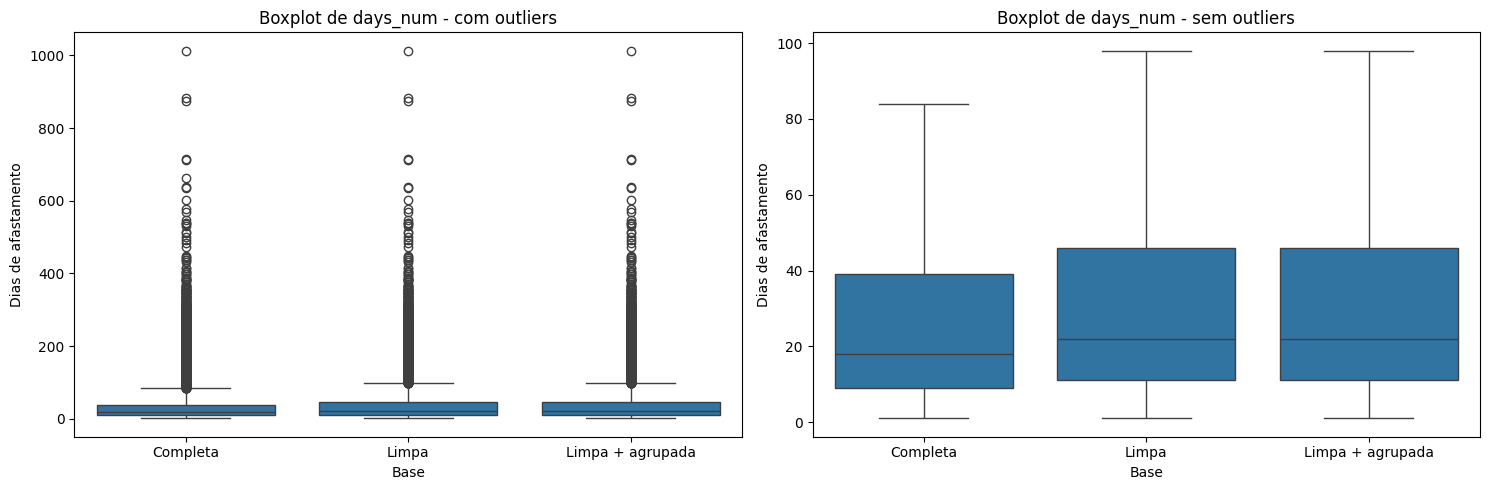

In [33]:
# =========================================================
# BOXPLOT COMPARANDO AS TRÊS BASES
# =========================================================

plot_compare_3 = pd.concat([
    pd.DataFrame({
        "dataset": "Completa",
        "days_num": df_model["days_num"]
    }),
    pd.DataFrame({
        "dataset": "Limpa",
        "days_num": df_model_clean["days_num"]
    }),
    pd.DataFrame({
        "dataset": "Limpa + agrupada",
        "days_num": df_model_grouped["days_num"]
    })
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_compare_3, x="dataset", y="days_num", ax=axes[0])
axes[0].set_title("Boxplot de days_num - com outliers")
axes[0].set_xlabel("Base")
axes[0].set_ylabel("Dias de afastamento")

sns.boxplot(data=plot_compare_3, x="dataset", y="days_num", showfliers=False, ax=axes[1])
axes[1].set_title("Boxplot de days_num - sem outliers")
axes[1].set_xlabel("Base")
axes[1].set_ylabel("Dias de afastamento")

plt.tight_layout()
plt.show()

In [39]:
# =========================================================
# FUNÇÃO DE AVALIAÇÃO
# =========================================================

def avaliar_modelo(dataframe, nome_base, usar_grupo=False):
    base = dataframe.copy()

    if usar_grupo:
        X = base.drop(columns=["days_num"])
    else:
        X = base.drop(columns=["days_num"])

    y = base["days_num"]

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols)
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(steps=[
        ("preprocessamento", preprocessor),
        ("modelo", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    return {
        "Dataset": nome_base,
        "Registros": len(base),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

In [38]:
# =========================================================
# COMPARAÇÃO FINAL ENTRE 3 VERSÕES
# =========================================================

resultado_completo = avaliar_modelo(df_model, "Completa", usar_grupo=False)
resultado_limpo = avaliar_modelo(df_model_clean, "Limpa", usar_grupo=False)
resultado_agrupado = avaliar_modelo(df_model_grouped, "Limpa + agrupada", usar_grupo=True)

comparacao_final = pd.DataFrame([
    resultado_completo,
    resultado_limpo,
    resultado_agrupado
])

comparacao_final["MAE"] = comparacao_final["MAE"].round(2)
comparacao_final["RMSE"] = comparacao_final["RMSE"].round(2)
comparacao_final["R2"] = comparacao_final["R2"].round(3)

display(comparacao_final)

,Dataset,Registros,MAE,RMSE,R2
0,Completa,15603,8.94,16.98,0.887
1,Limpa,12482,10.48,18.97,0.891
2,Limpa + agrupada,12482,10.35,18.75,0.893
